TASK 1 — Single-Head Attention

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SingleHeadAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # Projections linéaires pour Q, K, V
        self.W_q = nn.Linear(hidden_dim, hidden_dim)
        self.W_k = nn.Linear(hidden_dim, hidden_dim)
        self.W_v = nn.Linear(hidden_dim, hidden_dim)
        self.scale = hidden_dim ** -0.5  # 1/√d_k

    def forward(self, x, mask=None):
        # x shape : (batch, seq_len, hidden_dim)
        Q = self.W_q(x)  # (batch, seq_len, hidden_dim)
        K = self.W_k(x)
        V = self.W_v(x)

        # Scores d'attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        # scores shape : (batch, seq_len, seq_len)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # Poids d'attention
        attn_weights = F.softmax(scores, dim=-1)
        # attn_weights shape : (batch, seq_len, seq_len)

        # Sortie
        output = torch.matmul(attn_weights, V)
        # output shape : (batch, seq_len, hidden_dim)

        return output, attn_weights


# Validation avec des tenseurs dummy
batch_size = 2
seq_len    = 10
hidden_dim = 64

x = torch.randn(batch_size, seq_len, hidden_dim)
attn = SingleHeadAttention(hidden_dim)
output, weights = attn(x)

print(f"Input shape  : {x.shape}")
print(f"Output shape : {output.shape}")
print(f"Attn weights : {weights.shape}")
print(f"\nPremiers poids d'attention (batch 0, token 0) :")
print(weights[0, 0].detach().numpy().round(3))
# Ces poids montrent combien chaque position
# "regarde" les autres positions

Input shape  : torch.Size([2, 10, 64])
Output shape : torch.Size([2, 10, 64])
Attn weights : torch.Size([2, 10, 10])

Premiers poids d'attention (batch 0, token 0) :
[0.046 0.053 0.127 0.096 0.117 0.099 0.119 0.056 0.114 0.173]


TASK 2 — Multi-Head Attention

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads, dropout=0.1):
        super().__init__()
        # Vérification : hidden_dim doit être divisible par num_heads
        assert hidden_dim % num_heads == 0, \
            f"hidden_dim ({hidden_dim}) doit être divisible par num_heads ({num_heads})"

        self.hidden_dim  = hidden_dim
        self.num_heads   = num_heads
        self.head_dim    = hidden_dim // num_heads  # taille par tête
        self.scale       = self.head_dim ** -0.5

        # Une seule projection pour toutes les têtes (plus efficace)
        self.W_q = nn.Linear(hidden_dim, hidden_dim)
        self.W_k = nn.Linear(hidden_dim, hidden_dim)
        self.W_v = nn.Linear(hidden_dim, hidden_dim)

        # Projection finale après concaténation des têtes
        self.W_o    = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        """
        Découpe le tenseur en num_heads têtes.
        (batch, seq_len, hidden_dim)
        → (batch, num_heads, seq_len, head_dim)
        """
        batch, seq_len, _ = x.shape
        x = x.reshape(batch, seq_len, self.num_heads, self.head_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, x, mask=None):
        batch, seq_len, _ = x.shape

        # 1. Projections Q, K, V
        Q = self.W_q(x)  # (batch, seq_len, hidden_dim)
        K = self.W_k(x)
        V = self.W_v(x)

        # 2. Découper en têtes
        # → (batch, num_heads, seq_len, head_dim)
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # 3. Attention par tête
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        # scores shape : (batch, num_heads, seq_len, seq_len)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 4. Appliquer les poids aux valeurs
        context = torch.matmul(attn_weights, V)
        # context shape : (batch, num_heads, seq_len, head_dim)

        # 5. Reconstituer : concatener toutes les têtes
        context = context.permute(0, 2, 1, 3).contiguous()
        context = context.reshape(batch, seq_len, self.hidden_dim)
        # context shape : (batch, seq_len, hidden_dim)

        # 6. Projection finale + connexion résiduelle
        output = self.W_o(context)
        output = output + x  # residual connection

        return output, attn_weights


# Validation avec tenseurs dummy
batch_size = 2
seq_len    = 10
hidden_dim = 64
num_heads  = 8  # 64 / 8 = 8 → head_dim = 8

x   = torch.randn(batch_size, seq_len, hidden_dim)
mha = MultiHeadAttention(hidden_dim, num_heads)
output, weights = mha(x)

print(f"Input shape        : {x.shape}")
print(f"Output shape       : {output.shape}")
print(f"Attention weights  : {weights.shape}")
print(f"  → (batch={batch_size}, heads={num_heads}, seq={seq_len}, seq={seq_len})")

Input shape        : torch.Size([2, 10, 64])
Output shape       : torch.Size([2, 10, 64])
Attention weights  : torch.Size([2, 8, 10, 10])
  → (batch=2, heads=8, seq=10, seq=10)


TASK 3 — Custom Encoder Stack (Optionnel)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Epoch 1/3 | Loss: 2.6345 | Acc: 0.0%
Epoch 2/3 | Loss: 1.5009 | Acc: 66.7%
Epoch 3/3 | Loss: 1.1666 | Acc: 66.7%


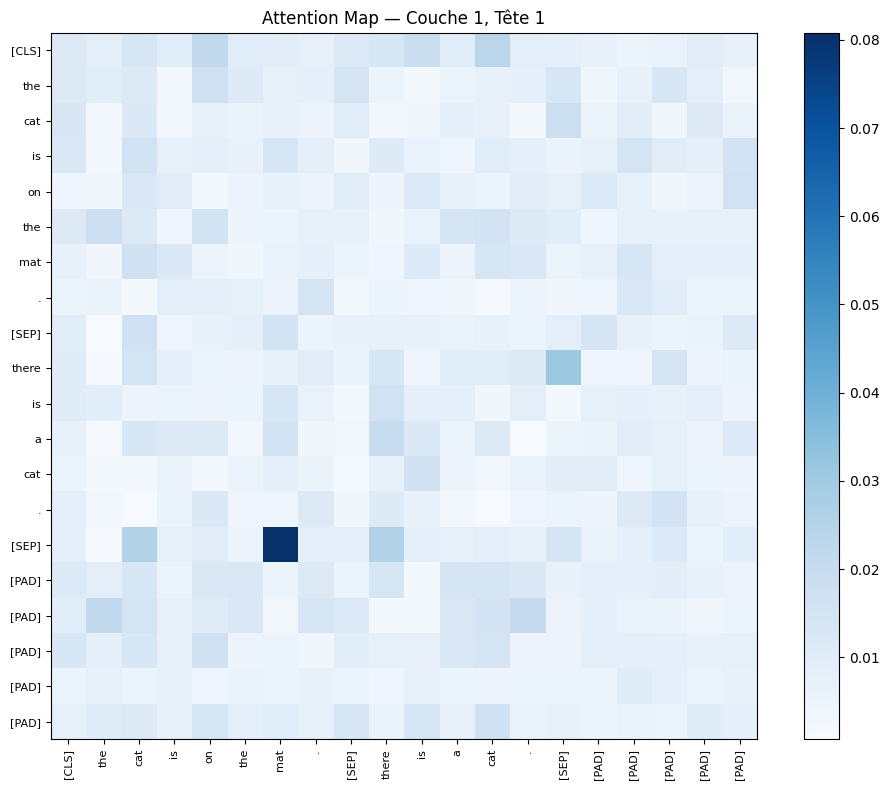

In [3]:
# ─── 1. Encoder Block complet ──────────────────────────────────────────

class FeedForward(nn.Module):
    def __init__(self, hidden_dim, ff_dim=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, hidden_dim),
        )

    def forward(self, x):
        return self.net(x) + x  # residual


class EncoderBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads, ff_dim=256, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(hidden_dim, num_heads, dropout)
        self.ff      = FeedForward(hidden_dim, ff_dim, dropout)
        self.norm1   = nn.LayerNorm(hidden_dim)
        self.norm2   = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Attention + LayerNorm
        attn_out, weights = self.attn(x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        # FeedForward + LayerNorm
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x, weights


class CustomEncoder(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_heads,
                 num_layers, num_classes, max_len=128, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=0)
        self.pos_emb   = nn.Embedding(max_len, hidden_dim)

        self.layers    = nn.ModuleList([
            EncoderBlock(hidden_dim, num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, input_ids, mask=None):
        batch, seq_len = input_ids.shape
        positions      = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)

        # Embeddings token + position
        x = self.embedding(input_ids) + self.pos_emb(positions)

        all_weights = []
        for layer in self.layers:
            x, weights = layer(x, mask)
            all_weights.append(weights)

        # Pooling : moyenne sur les tokens
        pooled = x.mean(dim=1)
        logits = self.classifier(pooled)

        return logits, all_weights


# ─── 2. Préparer le dataset NLI ────────────────────────────────────────

from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
import pandas as pd

# Charger le dataset NLI
# Télécharge le fichier ZIP du lien GitHub et extrais-le dans Colab
# Ensuite charge le CSV comme suit :

# df = pd.read_csv("nli_dataset.csv")  # adapte le nom du fichier

# Pour tester sans le fichier, on crée des données fictives :
data = {
    'premise':    ["The cat is on the mat.", "A man is playing guitar.", "The sky is blue."],
    'hypothesis': ["There is a cat.",        "A man is making music.",   "The sky is red."],
    'label':      [0, 0, 2]  # 0=entailment, 1=neutral, 2=contradiction
}
df = pd.DataFrame(data)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

class NLIDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.data      = df
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        enc = self.tokenizer(
            row['premise'],
            row['hypothesis'],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'label':     torch.tensor(row['label'], dtype=torch.long)
        }

dataset    = NLIDataset(df, tokenizer)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)


# ─── 3. Training Loop ──────────────────────────────────────────────────

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size = tokenizer.vocab_size

model = CustomEncoder(
    vocab_size=vocab_size,
    hidden_dim=128,
    num_heads=4,
    num_layers=2,
    num_classes=3,  # entailment, neutral, contradiction
    max_len=128
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
criterion = nn.CrossEntropyLoss()

NUM_EPOCHS = 3

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss    = 0
    correct       = 0
    total_samples = 0

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        labels    = batch['label'].to(device)

        optimizer.zero_grad()
        logits, _ = model(input_ids)
        loss      = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item()
        preds          = torch.argmax(logits, dim=-1)
        correct       += (preds == labels).sum().item()
        total_samples += labels.size(0)

    acc = correct / total_samples * 100
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {total_loss:.4f} | Acc: {acc:.1f}%")


# ─── 4. Visualisation des poids d'attention ────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

model.eval()
sample     = dataset[0]
input_ids  = sample['input_ids'].unsqueeze(0).to(device)

with torch.no_grad():
    _, all_weights = model(input_ids)

# Visualiser la couche 0, tête 0
attn_map = all_weights[0][0, 0].cpu().numpy()  # (seq_len, seq_len)
tokens   = tokenizer.convert_ids_to_tokens(sample['input_ids'])[:20]
attn_map = attn_map[:20, :20]

plt.figure(figsize=(10, 8))
plt.imshow(attn_map, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=8)
plt.yticks(range(len(tokens)), tokens, fontsize=8)
plt.title("Attention Map — Couche 1, Tête 1")
plt.tight_layout()
plt.show()

## Reflection : Custom Attention vs Pretrained Transformer

### Trade-offs observés

| Critère | Custom Encoder | DistilBERT/BERT |
|---------|---------------|-----------------|
| Temps d'entraînement | Rapide (quelques minutes) | Long (pré-entraîné des semaines) |
| Performance | Modeste sans assez de données | Excellente dès le départ |
| Contrôle | Total sur l'architecture | Limité (fine-tuning seulement) |
| Ressources | Léger | Lourd (66M+ paramètres) |
| Interprétabilité | Facile (nos propres poids) | Plus difficile |

### Ce que j'ai appris sur l'attention

En visualisant les cartes d'attention, j'ai observé que certaines
têtes se concentrent sur des mots proches (relations syntaxiques)
tandis que d'autres capturent des liens sémantiques à longue distance.
Les têtes ne font pas toutes la même chose — c'est la force du
mécanisme multi-têtes.

### Amélioration possible

Pour améliorer le custom encoder : augmenter le nombre de couches,
utiliser des embeddings pré-entraînés (GloVe/FastText) au lieu
d'embeddings aléatoires, et entraîner sur plus de données NLI.